/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

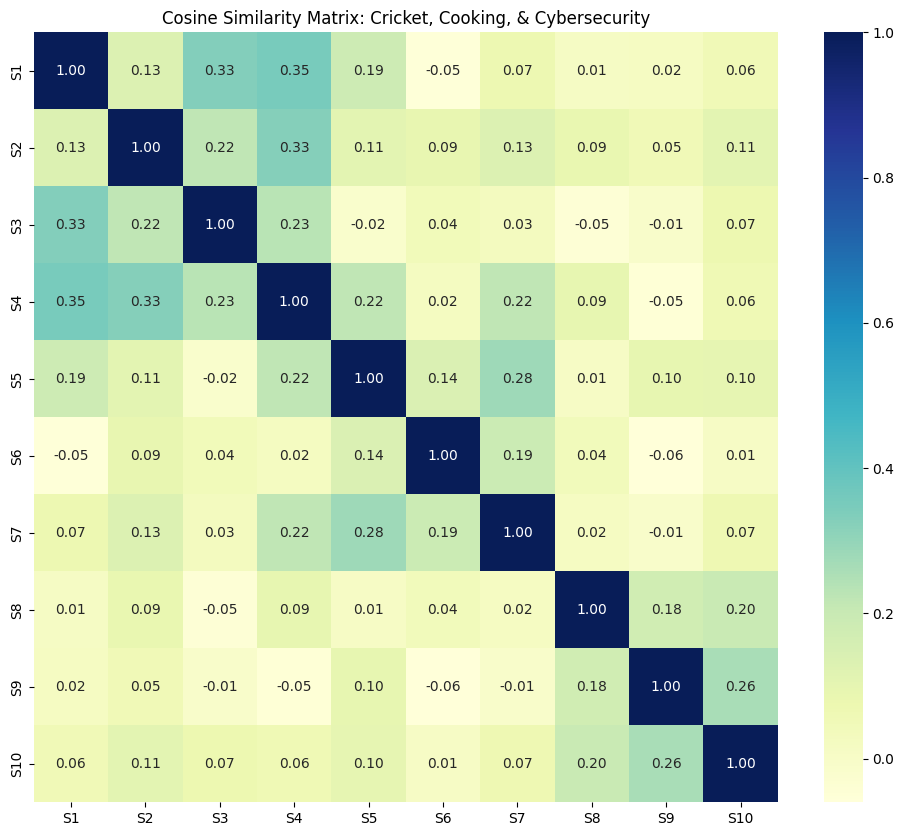

Query: "The bowler took three wickets in one over"

Top 2 Most Similar Sentences:
- The batsman hit a massive six over the long-on boundary. (Similarity Score: 0.5319)
- The test match ended in an exciting draw after five days of play. (Similarity Score: 0.3156)


In [1]:
# Step 1: Install necessary libraries
# !pip install sentence-transformers matplotlib seaborn

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

# 1. Define 10 sentences across 3 topics: Cricket, Cooking, and Cybersecurity
sentences = [
    # Cricket
    "The batsman hit a massive six over the long-on boundary.",
    "Spinners rely on the drift and turn of the ball to deceive players.",
    "The test match ended in an exciting draw after five days of play.",
    "Fielding at point requires incredibly fast reflexes and agility.",

    # Cooking
    "Slow-roasting the meat ensures it remains tender and juicy.",
    "Adding fresh basil at the end preserves its vibrant herbal aroma.",
    "Whisking the egg whites to stiff peaks is essential for a soufflé.",

    # Cybersecurity
    "Multi-factor authentication significantly reduces the risk of unauthorized access.",
    "Ransomware attacks encrypt sensitive files and demand payment for the key.",
    "Regularly patching software vulnerabilities is a critical security practice."
]

# 2. Generate embeddings using sentence-transformers (all-MiniLM-L6-v2)
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

# 3. Compute and display a 10x10 cosine similarity matrix as a heatmap
cosine_sim_matrix = util.cos_sim(embeddings, embeddings).cpu().numpy()

plt.figure(figsize=(12, 10))
sns.heatmap(
    cosine_sim_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=[f"S{i+1}" for i in range(10)],
    yticklabels=[f"S{i+1}" for i in range(10)]
)
plt.title("Cosine Similarity Matrix: Cricket, Cooking, & Cybersecurity")
plt.show()

# 4. Find top 2 most similar sentences for the new query
query_sentence = "The bowler took three wickets in one over"
query_embedding = model.encode(query_sentence, convert_to_tensor=True)

# Compute similarities between query and all stored sentences
search_hits = util.cos_sim(query_embedding, embeddings)[0]

# Get the indices of the top 2 scores
top_2_indices = np.argsort(-search_hits.cpu().numpy())[:2]

print(f"Query: \"{query_sentence}\"\n")
print("Top 2 Most Similar Sentences:")
for idx in top_2_indices:
    score = search_hits[idx].item()
    print(f"- {sentences[idx]} (Similarity Score: {score:.4f})")